# Hyperparameter? I Hardly Know'er!

In this project, we implement the **Sequential Convexification** (SCvx) Algorithm to solve a nonlinear rocket landing trajectory optimization problem on the Moon

We consider a simplified rocket modeled after an inverted cart-pole with thrust vectoring capabilities:
- The rocket is represented as an **inverted pendulum** mounted on a movable base.
- The system consists of:
    - A thruster/base with mass $m_t$ (the "cart")
    - A rocket body with mass $m_b$ and length $\ell$ (the "pole")
    - The rocket can move freely in 2D and rotate about its base.

**State Vector**: $x = [p_x, p_z, \theta, \dot{p}_x, \dot{p}_z, \dot{\theta}]^T$, where:
- $(p_x, p_z)$: position of the rocket base
- $\theta$: angle from vertical (upright is $\theta = 0$), with clockwise positive
- $(\dot{p}_x, \dot{p}_z)$: velocities of the base
- $\omega = \dot{\theta}$: angular velocity of the rocket body

**Control Input**: $u = [T_{\text{base},x}, T_{\text{base},z}, T_{\text{nose},x}]^T$, representing thrust at the rocket base and nose.

**Objective**: Starting from a high altitude with initial velocity, the task is to **land the rocket softly** on a designated landing pad, satisfying:
- Low final velocities
- Upright orientation ($\theta \approx 0$)
- Accurate landing pad placement

**Constraints**:
1. **Thrust Limits**: Both upper and lower bounds on horizontal and vertical thrusts
2. **Landing Zone**: Final position must be within the designated landing region
3. **Obstacle Avoidance**: The trajectory must avoid specified circular no-fly zones


In [26]:
import functools
from typing import Callable

import cvxpy as cp
import dynamaxsys
import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np
from RocketDynamics import RocketDynamics
from utils import (
    PD_controller,
    animate_rocket_trajectory,
    closed_loop_sim,
    open_loop_sim,
    plot_rocket_trajectory,
)
from scp_mpc import (  # TODO: remove most of these function calls from the main notebook
    SQP,
    linearize_trajectory,
)

Now, set up the dynamics and other parameters. We will be using the helper function `closed_loop_sim` to simulate the dynamics given a closed-loop controller.

In [27]:
# feel free to adjust the parameters to see how they affect the rocket's behavior
params = {
    "mass_thruster": 10.0,  # mass of the thruster
    "mass_body": 15,  # mass of the rocket body
    "length": 1.0,  # length of the rocket
    "gravity": 9.81,  # gravity constant
}
rocket_ct = RocketDynamics(params)
dt = 0.01
rocket_dt = dynamaxsys.get_discrete_time_dynamics(
    rocket_ct, dt=dt
)  # discrete time dynamics

# set up the control limits
thrust_to_weight_ratio = 1.3  # 1.3
rocket_weight = (params["mass_thruster"] + params["mass_body"]) * params["gravity"]
T_base_z_max = rocket_weight * thrust_to_weight_ratio  # vertical thrust limit
T_base_x_max = T_base_z_max * 0.75  # horizontal thrust limit; feel free to adjust this
T_nose_max = T_base_x_max * 0.75  # nose thrust limit; feel free to adjust this

# set up the lower and upper limits for the control inputs
lower = jnp.array(
    [-T_base_x_max, 0.0, -T_nose_max]
)  # lower limits for the control inputs
upper = jnp.array(
    [T_base_x_max, T_base_z_max, T_nose_max]
)  # upper limits for the control inputs
limits = [lower, upper]


target_state = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # target state

gains = {
    "Kp_x": 50.0,
    "Kd_x": 30.0,
    "Kp_z": 50.0,
    "Kd_z": 150.0,
    "Kp_theta": 150.0,  # 150.0
    "Kd_theta": 100.0,
}.values()

# set up the PD controller. Use functools.partial to fix the target, gains, and limits
controller = functools.partial(
    PD_controller, target=target_state, gains=gains, limits=limits
)

initial_state = jnp.array(
    [5.0, 15.0, -0.2, -0.2, -3.0, 0.0]
    # px, pz, theta, vx, vz, omega
)  # initial state; feel free to adjust this
n_steps = 350  # number of steps; feel free to adjust this
states, controls = closed_loop_sim(
    rocket_dt, initial_state, controller, n_steps
)  # simulate the dynamics given a closed-loop controller

# plot the trajectory
# plot_rocket_trajectory(states, controls, lower, upper)

In [28]:
# animate_rocket_trajectory(states, controls, thrust_limit = upper)

### (c) Land the rocket with SQP!

You may have noticed that tuning a good set of PD gains can be difficult, and even an effective gain set may only succeed for some initial conditions. The challenge of reliably landing the rocket motivates a more systematic approach.
Trajectory optimization allows us to compute the most efficient sequence of controls and states, while explicitly enforcing constraints to prevent the rocket from crashing and to satisfy other requirements.

Specifically, we aim to find a sequence of states $\{x_0, x_1, \ldots, x_N\}$ and controls $\{u_0, u_1, \ldots, u_{N-1}\}$ that minimizes the total weighted state and control effort, subject to the rocket ending at the origin (both in position, velocity, and angle), obeying the system dynamics, and respecting input limits:

$$
\begin{align*}
\text{minimize}_{x_{0:N},\, u_{0:N-1}} \quad & \sum_{k=0}^{N-1} x_k^\top Q x_k + u_k^\top R u_k \\
\text{subject to} \quad
     & x_{k+1} = f(x_k, u_k), \quad\;\; k = 0, \ldots, N-1 \\
     & x_0 = x_\text{init} \\
     & x_N = x_\text{target} \\
     & p_{z,k} \geq 0, \qquad k = 0, \ldots, N\\
     & u_\text{min} \leq u_k \leq u_\text{max}, \qquad k = 0, \ldots, N-1 \\
\end{align*}
$$

Here, $x_k$ is the full rocket state at step $k$, and $u_k$ is the control input at step $k$.
However, because the dynamics $f(x, u)$ are highly nonlinear, directly solving this optimization is extremely challenging.
In the next steps, you will implement the essential components for solving this problem via Sequential Quadratic Programming (SQP).


#### (i) Linearize dynamics

Notice in the trajectory optimization problem above that the objective is quadratic, and all constraints except for the dynamics are linear. This means the problem is almost a quadratic program (QP)!

To fully convert it into a QP, we need to linearize the dynamics constraint.

Next, let's linearize the dynamics along the state and control trajectory produced by your PD controller.
This process will yield linear, time-varying dynamics of the form:
$$
x_{k+1} = A_k x_k + B_k u_k + C_k
$$
where $A_k$, $B_k$, and $C_k$ are computed at each timestep $k$ along the trajectory.

These matrices capture the local, linear approximation of the true nonlinear dynamics at each point in time along the trajectory.
Thus, the system is described by *time-varying* linear dynamics.

To efficiently compute $A_k$, $B_k$, and $C_k$ for all timesteps, apply `jax.vmap` to `linearize_dynamics`.

In [29]:
# get a reference trajectory from the closed_loop_sim
states, controls = closed_loop_sim(rocket_dt, initial_state, controller, n_steps)

# linearize the dynamics about every state in the trajectory
As, Bs, Cs = linearize_trajectory(rocket_dt, states, controls)


#### (ii) Set up and solve the CVXPY problem
Having linearized the dynamics around a given trajectory, we can now formulate and solve a trajectory optimization problem using this linearized system.

The locally linearized, discrete-time dynamics are given by:

$$
\begin{align*}
x_{k+1} &= A_k x_k + B_k u_k + C_k, \qquad k = 0, ..., N-1 \\
\end{align*}
$$

where $A_k$, $B_k$, $C_k$ are the time-varying linearization matrices about $(\tilde{x}_k, \tilde{u}_k)$.

For the linearized system, we formulate the following quadratic program (QP):

$$
\begin{align*}
\underset{x_{0:N},\ u_{0:N-1}}{\text{minimize}} \quad
    & \sum_{k=0}^{N-1} \left(
        x_k^\top Q x_k
        + u_k^\top R u_k
        + (x_k - \tilde{x}_k)^\top Q_\mathrm{trp} (x_k - \tilde{x}_k)
        + (u_k - \tilde{u}_k)^\top R_\mathrm{trp} (u_k - \tilde{u}_k)
      \right) \\
    &\quad + (x_N - x_\mathrm{target})^\top Q_N (x_N - x_\mathrm{target}) \\
\text{subject to} \qquad
    & x_{k+1} = A_k x_k + B_k u_k + C_k, \quad   k = 0, ..., N-1 \\
    & x_0 = x_\mathrm{init} \\
    & p_{z,k} \geq 0, \qquad k = 0, \ldots, N\\
    & u_{\min} \leq u_k \leq u_{\max}, \qquad k = 0, ..., N-1 \\
\end{align*}
$$

Here, the matrices $Q_\mathrm{trp}$ and $R_\mathrm{trp}$ impose a *trust region penalty*, encouraging the optimized trajectory $(x_k, u_k)$ to stay close to the trajectory $(\tilde{x}_k, \tilde{u}_k)$ about which the dynamics were linearized. This is important because the quality of the linear approximation degrades further from the linearization points.
Rather than enforcing a hard terminal state constraint (which might be infeasible for a given horizon or control limits), we use a large terminal cost via $Q_N$ to softly encourage the final state to reach the desired target.
With these design choices, the problem becomes a convex quadratic program (QP) which we can efficiently solve using `cvxpy`.

Set up the corresponding `cvxpy` problem as described above.

In [30]:
state_dim = rocket_ct.state_dim  # 6, state dimension
control_dim = rocket_ct.control_dim  # 3, control dimension
n_steps = 300  # feel free to adjust number of steps.

# set up the cost matrices. Feel free to adjust these to see how they affect the optimization.
# Q = cp.Parameter((state_dim, state_dim), name="Q", PSD=True)
# encourage the rocket to stay upright and slow; state: [p_x, p_z, theta, v_x, v_z, omega]

# R = cp.Parameter((control_dim, control_dim), name="R", PSD=True)
# control cost matrix; control: [T_x, T_z, T_theta]

# QN = cp.Parameter((state_dim, state_dim), name="QN", PSD=True)
# terminal cost matrix; state: [p_x, p_z, theta, v_x, v_z, omega

# QTRP = cp.Parameter((state_dim, state_dim), name="QTRP", PSD=True)
# trust region penalty for state deviations.

# RTRP = cp.Parameter((control_dim, control_dim), name="RTRP", PSD=True)


# adjust cost matrices and resolve
Q = cp.Constant(
    np.diag([1.0, 0, 20.0, 0.5, 0.5, 10.0])
)  # encourage the rocket to stay upright and slow; state: [p_x, p_z, theta, v_x, v_z, omega]
R = cp.Constant(
    np.diag([0.0001, 0.0001, 0.00])
)  # control cost matrix; control: [T_x, T_z, T_theta]
QN = cp.Constant(
    np.diag([100.0, 500.0, 1000.0, 1000.0, 800.0, 500.0]) * 10
)  # terminal cost matrix; state: [p_x, p_z, theta, v_x, v_z, omega
QTRP = cp.Constant(
    np.eye(state_dim) * 100.0
)  # trust region penalty for state deviations.
RTRP = cp.Constant(
    np.eye(control_dim) * 100.0
)  # trust region penalty for control deviations.
# trust region penalty for control deviations.

In [31]:
# set up cvxpy optimization variables
states = cp.Variable(
    (n_steps + 1, state_dim),
    name="states"
)  # state trajectory [n_steps+1, state_dim]
controls = cp.Variable(
    (n_steps, control_dim),
    name="controls"
)  # control trajectory [n_steps, control_dim]
theta_slack = cp.Variable(n_steps + 1, nonneg=True)
ground_slack = cp.Variable(n_steps + 1, nonneg=True)

theta_slack_penalty = 1e5
ground_slack_penalty = 1e3

# set up the A, B, C matrices as parameters since they will be updated at each SQP iteration
As = cp.Parameter((n_steps, state_dim, state_dim), name="As")
Bs = cp.Parameter((n_steps, state_dim, control_dim), name="Bs")
Cs = cp.Parameter((n_steps, state_dim), name="Cs")

# set up the previous state and control parameters since they will be updated at each SQP iteration
previous_states = cp.Parameter((n_steps + 1, state_dim), name="previous_states")
previous_controls = cp.Parameter((n_steps, control_dim), name="previous_controls")

# set up the goal state as a parameter in case you want to change the goal state later on
target_state = cp.Parameter((state_dim), name="target_state")

# set up the initial state parameter in case you want to change the initial state later on
initial_state = cp.Parameter(state_dim, name="initial_state")

# set up control constraints
u_min = cp.Constant(lower, name="u_min")
u_max = cp.Constant(upper, name="u_max")

# calculate state and control deviations from the last solution for trust region penalty
state_deviation = states - previous_states
control_deviation = controls - previous_controls
terminal_state_error = states[-1] - target_state

# vectorize each cost matrix
Q_diag = np.diag(Q.value)
R_diag = np.diag(R.value)
QTRP_diag = np.diag(QTRP.value)
RTRP_diag = np.diag(RTRP.value)
QN_diag = np.diag(QN.value)

# elementwise multiplication with the states/controls at every time step via broadcasting
Q_cost = cp.sum(cp.multiply(Q_diag, cp.square(states[:n_steps, :])))
R_cost = cp.sum(cp.multiply(R_diag, cp.square(controls)))
QTRP_cost = cp.sum(cp.multiply(QTRP_diag, cp.square(state_deviation)))
RTRP_cost = cp.sum(cp.multiply(RTRP_diag, cp.square(control_deviation)))
QN_cost = cp.sum(cp.multiply(QN_diag, cp.square(terminal_state_error)))

# slack costs
slack_cost = cp.sum(theta_slack_penalty * theta_slack) + cp.sum(
    ground_slack_penalty * ground_slack
)

objective = Q_cost + R_cost + QTRP_cost + RTRP_cost + QN_cost + slack_cost

# constraints
dynamics_constraint = [
    states[k + 1] == As[k] @ states[k] + Bs[k] @ controls[k] + Cs[k]
    for k in range(n_steps)
]
initial_cond = states[0, :] == initial_state

THETA_LIMIT = 0.25  # rad
# tried to add this constraint but the solver failed: cp.abs(states[:, 2]) <= THETA_LIMIT
state_constraints = [
    states[:, 1] >= 0 - ground_slack,  # stay above ground
    states[:, 2] <= THETA_LIMIT + theta_slack,  # don't flip
    states[:, 2] >= -THETA_LIMIT - theta_slack,
]  # don't flip the other way either
control_constraints = [
    controls >= u_min,
    controls <= u_max,
]  # constrains all controls at all times
constraints = [
    *dynamics_constraint,
    initial_cond,
    *state_constraints,
    *control_constraints,
]

problem = cp.Problem(cp.Minimize(objective), constraints)


Now, compute and set the values for the Parameters and solve!

In [32]:
# target state value
target_state_value = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# initial state value
initial_state_value = np.array([1.0, 7.0, 0.1, 0.2, -0.1, -0.05])

# previous states and controls values using the outputs of the PD controller
previous_states_values, previous_controls_values = closed_loop_sim(
    rocket_dt, initial_state_value, controller, n_steps
)

# linearize the dynamics about the previous states and controls
As_values, Bs_values, Cs_values = linearize_trajectory(
    rocket_dt, previous_states_values, previous_controls_values
)
# As_values, Bs_values, Cs_values = jax.vmap(linearize_dynamics, in_axes=(None, 0, 0))(
#     rocket_dt, previous_states_values[:-1], previous_controls_values
# )


In [33]:
# set the values for the parameters. Convert to numpy array to avoid issues with cvxpy.
As.value = np.array(As_values)
Bs.value = np.array(Bs_values)
Cs.value = np.array(Cs_values)

previous_states.value = np.array(previous_states_values)
previous_controls.value = np.array(previous_controls_values)

target_state.value = target_state_value
initial_state.value = initial_state_value

# solve the problem
problem.solve(solver=cp.CLARABEL)
print(f"Cost: {problem.value}")
print(f"Status: {problem.status}")

Cost: 29782.964570335378
Status: optimal


## What the solver thought would happen

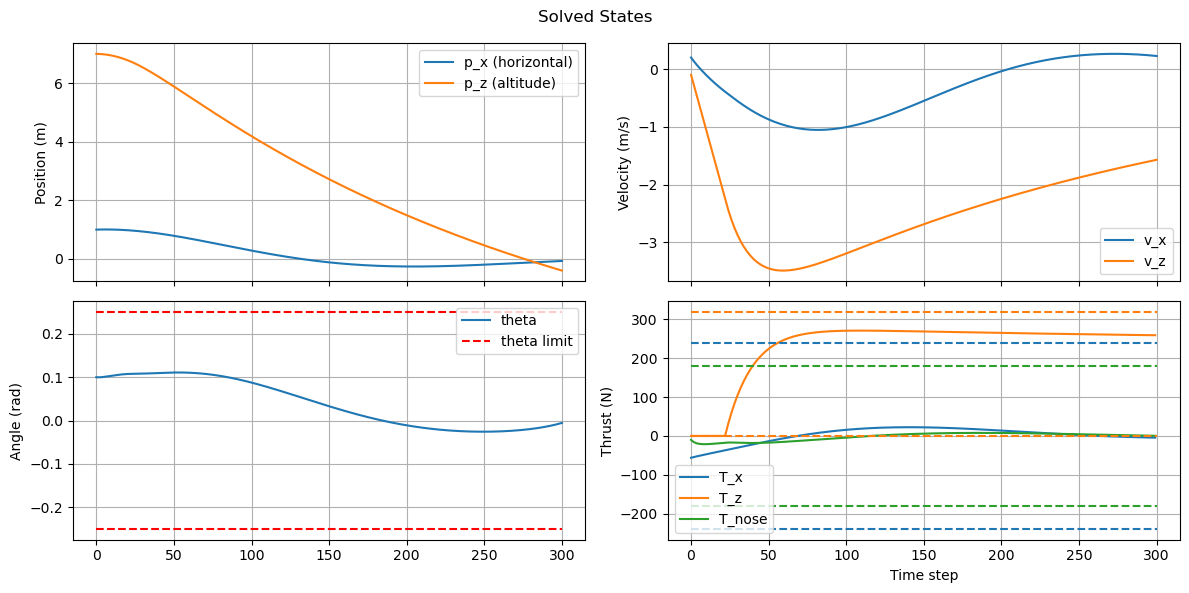

In [34]:
plot_rocket_trajectory(
    states.value,
    controls.value,
    lower,
    upper,
    title="Solved States",
    theta_limit=THETA_LIMIT,
)

In [35]:
# animate_rocket_trajectory(states.value, controls.value, thrust_limit=upper)

## What actually happend

In [36]:
# compute states with true nonlinear dynamics. Recall that states.value is the optimized trajectory based on linearized dynamics.
open_loop_states = open_loop_sim(rocket_dt, initial_state_value, controls.value)

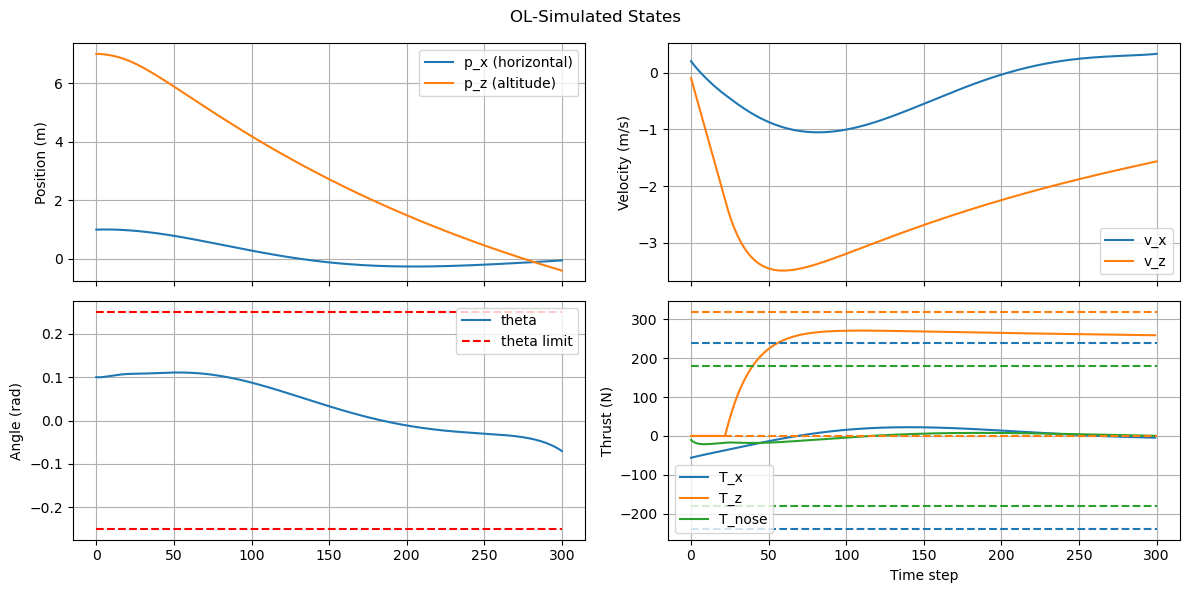

In [37]:
plot_rocket_trajectory(
    open_loop_states,
    controls.value,
    lower,
    upper,
    title="OL-Simulated States",
    theta_limit=THETA_LIMIT,
)

In [ ]:
# animate_rocket_trajectory(open_loop_states, controls.value, thrust_limit=upper)

#### (iii) Perform Sequential Quadratic Programming (SQP) Iterations
So far, you have completed a single SQP iteration. The power of SQP comes from repeating this process:
linearizing around the current trajectory, solving the optimization, and then updating the trajectory based on the new solution.

Implement a loop to carry out multiple SQP iterations. After each iteration, use the latest solution (states/controls) as the new nominal trajectory about which to linearize for the next step. Continue this process to progressively improve the trajectory.

In [39]:
# setting up the problem again

# target state value
target_state_value = np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
)  # feel free to adjust target state

# initial state value
initial_state_value = np.array(
    [1.0, 7.0, 0.1, 0.2, -0.1, -0.05]
)  # feel free to adjust initial state

# previous states and controls values using the outputs of the PD controller
previous_states_values, previous_controls_values = closed_loop_sim(
    rocket_dt, initial_state_value, controller, n_steps
)
# print(previous_states_values)

# set the values for the parameters.
target_state.value = target_state_value
initial_state.value = initial_state_value

In [41]:
# do it with module instead
initial_guess = {
    "states": previous_states_values,
    "controls": previous_controls_values,
}

n_sqp_iterations = 50

controls_list, solver_states_list, costs, status_list = SQP(
    problem, rocket_dt, initial_guess, convergence_tol=1e-6, max_sqp_iterations=n_sqp_iterations, verbose=True
)

# convert to np.arrays for plotting
controls_list = np.array(controls_list)
solver_states_list = np.array(solver_states_list)

# use nonlinear open-loop sim to get true states
states_list = jax.vmap(open_loop_sim, in_axes=(None, None, 0))(
    rocket_dt, initial_state.value, controls_list
)

SQP iteration 1/50	 Status: optimal	 Cost: 29782.964570335324
SQP iteration 2/50	 Status: optimal	 Cost: 28855.028046753054
SQP iteration 3/50	 Status: optimal	 Cost: 27638.000703920738
SQP iteration 4/50	 Status: optimal	 Cost: 26571.19171330854
SQP iteration 5/50	 Status: optimal	 Cost: 25753.97747250931
SQP iteration 6/50	 Status: optimal	 Cost: 24849.079139644087
SQP iteration 7/50	 Status: optimal	 Cost: 24172.901061467266
SQP iteration 8/50	 Status: optimal	 Cost: 23536.989686265515
SQP iteration 9/50	 Status: optimal	 Cost: 22790.0592608792
SQP iteration 10/50	 Status: optimal	 Cost: 22180.703709196554
SQP iteration 11/50	 Status: optimal	 Cost: 21651.55511767654
SQP iteration 12/50	 Status: optimal	 Cost: 21178.256779995496
SQP iteration 13/50	 Status: optimal	 Cost: 20738.91073670634
SQP iteration 14/50	 Status: optimal	 Cost: 20358.399502058033
SQP iteration 15/50	 Status: optimal	 Cost: 19988.005786190275
SQP iteration 16/50	 Status: optimal	 Cost: 19679.391235906813
SQP ite

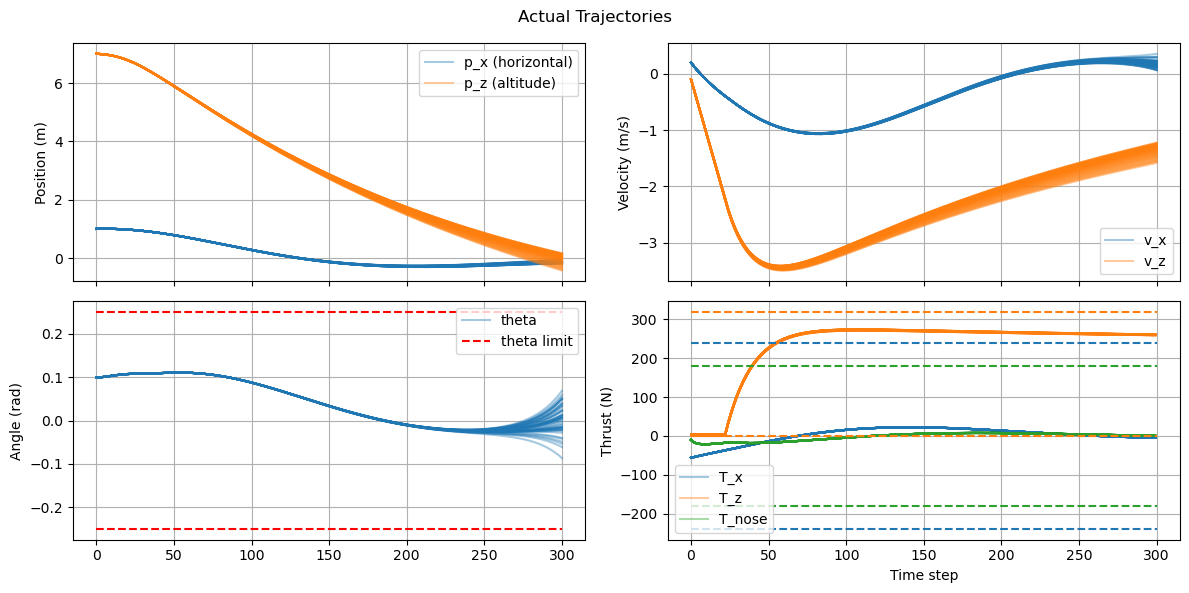

In [42]:
# plot all the trajectories for each SQP iteration
# plot_rocket_trajectory(
#     solver_states_list,
#     controls_list,
#     lower,
#     upper,
#     theta_limit=THETA_LIMIT,
#     title="Solver Trajectories",
# )
plot_rocket_trajectory(
    states_list,
    controls_list,
    lower,
    upper,
    theta_limit=THETA_LIMIT,
    title="Actual Trajectories",
)

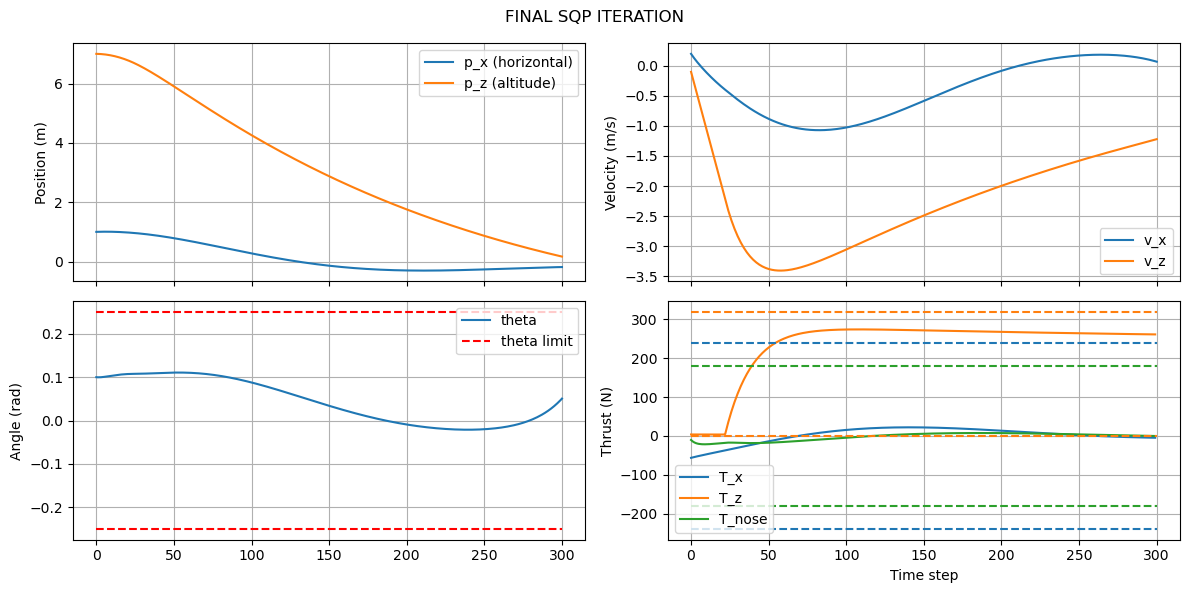

In [43]:
plot_rocket_trajectory(
    states_list[-1],
    controls_list[-1],
    lower,
    upper,
    theta_limit=THETA_LIMIT,
    title="FINAL SQP ITERATION",
)

In [44]:
# animate the last trajectory from the SQP iterations
animate_rocket_trajectory(states_list[-1], controls_list[-1], thrust_limit=upper)

## Now lets make it MPC!

We need to define a new optimization problem with shorter horizon and update the initial state every MPC iteration

In [ ]:
state_dim = rocket_ct.state_dim  # 6, state dimension
control_dim = rocket_ct.control_dim  # 3, control dimension
mpc_horizon_steps = 15  # Prediction horizon NOTE: full landing traj was ~300 steps

In [ ]:
Q = cp.Constant(
    np.diag([1.0, 0, 20.0, 0.5, 0.5, 10.0])
)  # encourage the rocket to stay upright and slow; state: [p_x, p_z, theta, v_x, v_z, omega]
R = cp.Constant(
    np.diag([0.0001, 0.0001, 0.00])
)  # control cost matrix; control: [T_x, T_z, T_theta]
QN = cp.Constant(
    np.diag([100.0, 500.0, 1000.0, 1000.0, 800.0, 500.0]) * 10
)  # terminal cost matrix; state: [p_x, p_z, theta, v_x, v_z, omega
QTRP = cp.Constant(
    np.eye(state_dim) * 100.0
)  # trust region penalty for state deviations.
RTRP = cp.Constant(
    np.eye(control_dim) * 100.0
)  # trust region penalty for control deviations.
# trust region penalty for control deviations.



states_list, controls_list = closed_loop_sim(
    rocket_dt,)

We wish to solve the following quadratic program at each time step:

## [CHANGE TO SCvx]

$$
\min_{\mathbf{u}_0, \ldots, \mathbf{u}_{N-1}} \sum_{k=0}^{N-1} \left[ (\mathbf{x}_k - \mathbf{x}_{\text{ref},k})^\top Q (\mathbf{x}_k - \mathbf{x}_{\text{ref},k}) + \mathbf{u}_k^\top R \mathbf{u}_k \right] + (\mathbf{x}_N - \mathbf{x}_{\text{ref},N})^\top Q_f (\mathbf{x}_N - \mathbf{x}_{\text{ref},N})
$$

subject to:
$$
\mathbf{x}_{k+1} = A \mathbf{x}_k + B \mathbf{u}_k, \quad k = 0, \ldots, N-1
$$
$$
\mathbf{x}_0 = \mathbf{x}_\mathrm{current}
$$

Apply only the first control $\mathbf{u}_0$, then repeat (receding horizon).


## Hyperparameter Sweep

We want to sweep through the following hyperparameter values with 100 linearly-interpolated values:

| Hyperparameter | Lower Bound | Upper Bound |
| --- | --- | --- |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |
| womp | womp | womp |

With 10 manually generated initial conditions: 

$$
x_0 = \begin{bmatrix}
    womp \\ womp \\ womp
\end{bmatrix}
$$

For each trial, we will collect all hyperparemter values and the intitial state, as well as the following performance metrics and store them in a pandas dataframe
1. Landing accuracy
2. Solve time per MPC iteration
3. Number of SCP iterations to converge (per MPC step)
4. Fuel used
5. Number of times the solver gives an infeasible solution
6. Number of slacked constraint violations
